In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import random

seed = 100

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
env = gym.make('Acrobot-v1')
state, info = env.reset(seed=seed)
env.action_space.seed(seed)
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Hyperparameters adjusted for Acrobot-v1
REPLAY_MEMORY_SIZE = 10000 # adjusted
BATCH_SIZE = 32  # the same as paper
GAMMA = 0.99    # the same as paper
TARGET_UPDATE_FREQ = 100  # adjusted
LEARNING_RATE = 0.00025    # the same as paper
RMS_DECAY = 0.95      # the same as paper
RMS_MOMENTUM = 0.95   # the same as paper
RMS_EPSILON = 0.01   # the same as paper
EPSILON_START = 1.0   # the same as paper
EPSILON_END = 0.1    # the same as paper
EPSILON_DECAY_STEPS = 2000   # adjusted
Experience = namedtuple('Experience', field_names=['state', 'action', 'reward', 'next_state', 'done'])

Using device: cuda


In [2]:

class QNetwork(nn.Module):
    def __init__(self):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


class DuelingQNetwork(nn.Module):
    def __init__(self):
        super(DuelingQNetwork, self).__init__()
        # Shared feature extractor
        self.fc1 = nn.Linear(state_size, 128)

        # Value stream
        self.value_fc = nn.Linear(128, 128)
        self.value = nn.Linear(128, 1)

        # Advantage stream
        self.advantage_fc = nn.Linear(128, 128)
        self.advantage = nn.Linear(128, action_size)

    def forward(self, x):
        # Shared layers
        x = torch.relu(self.fc1(x))

        # Value stream
        value = torch.relu(self.value_fc(x))
        value = self.value(value)

        # Advantage stream
        advantage = torch.relu(self.advantage_fc(x))
        advantage = self.advantage(advantage)

        # Combine value and advantage
        # Q(s,a) = V(s) + (A(s,a) - mean(A(s,a)))
        return value + advantage - advantage.mean(dim=1, keepdim=True)


In [3]:
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append(Experience(state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [4]:
class DQNAgent:
    def __init__(self, network_type="standard"):
        if network_type == "standard":
            self.policy_net = QNetwork().to(device)
            self.target_net = QNetwork().to(device)
        elif network_type == "dueling":
            self.policy_net = DuelingQNetwork().to(device)
            self.target_net = DuelingQNetwork().to(device)
        else:
            raise ValueError("network_type must be 'standard' or 'dueling'")

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.RMSprop(
            self.policy_net.parameters(),
            lr=LEARNING_RATE,
            alpha=RMS_DECAY,
            momentum=RMS_MOMENTUM,
            eps=RMS_EPSILON,
            centered=False
        )

        self.memory = ReplayMemory(REPLAY_MEMORY_SIZE)
        self.step_count = 0
        self.network_type = network_type

    def select_action(self, state, epsilon):
        state = torch.FloatTensor(state).unsqueeze(0).to(device)

        if random.random() > epsilon:
            with torch.no_grad():
                return self.policy_net(state).max(1)[1].item()
        else:
            return random.randrange(action_size)

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return

        experiences = self.memory.sample(BATCH_SIZE)
        batch = Experience(*zip(*experiences))

        state_batch = torch.FloatTensor(np.array(batch.state)).to(device)
        action_batch = torch.LongTensor(np.array(batch.action)).unsqueeze(1).to(device)
        reward_batch = torch.FloatTensor(np.array(batch.reward)).unsqueeze(1).to(device)
        next_state_batch = torch.FloatTensor(np.array(batch.next_state)).to(device)
        done_batch = torch.FloatTensor(np.array(batch.done)).unsqueeze(1).to(device)

        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        with torch.no_grad():
            next_state_values = self.target_net(next_state_batch).max(1)[0].unsqueeze(1)

        expected_state_action_values = torch.where(
            done_batch == 1,
            reward_batch,
            reward_batch + GAMMA * next_state_values
        )

        loss = nn.SmoothL1Loss()(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1

        if self.step_count % TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

In [5]:
def train(num_episodes=500, max_steps=500, network_type="standard"):
    agent = DQNAgent(network_type=network_type)
    scores = []
    total_steps = 0
    epoch_size = 10
    epoch_scores = []

    print(f"Starting {network_type.capitalize()} DQN training for Acrobot-v1")

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset()
        total_reward = 0

        for t in range(max_steps):
            decay_progress = min(total_steps / EPSILON_DECAY_STEPS, 1.0)
            current_epsilon = EPSILON_START - decay_progress * (EPSILON_START - EPSILON_END)
            epsilon = max(EPSILON_END, current_epsilon)

            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            total_steps += 1

            agent.optimize_model()

            if done:
                break

        scores.append(total_reward)

        if episode % epoch_size == 0:
            epoch_scores.append(np.mean(scores[-epoch_size:]))
            print(f"Epoch {len(epoch_scores)}, Average score: {epoch_scores[-1]:.2f}, Epsilon: {epsilon:.3f}, steps: {total_steps}")

        if episode % 100 == 0:
            avg_score = np.mean(scores[-100:])
            print(f"Episode {episode}\tAverage Score (100 episodes): {avg_score:.2f}")

        if episode >= 100 and np.mean(scores[-100:]) >= -100.0:
            print(f"\nEnvironment solved in {episode} episodes. Average Score (100 episodes): {np.mean(scores[-100:]):.2f}")
            break

    return scores, epoch_scores


--- Running baseline with standard DQN ---
Starting Standard DQN training for Acrobot-v1
Epoch 1, Average score: -388.30, Epsilon: 0.100, steps: 3889
Epoch 2, Average score: -203.10, Epsilon: 0.100, steps: 5930
Epoch 3, Average score: -204.70, Epsilon: 0.100, steps: 7987
Epoch 4, Average score: -310.90, Epsilon: 0.100, steps: 11105
Epoch 5, Average score: -265.60, Epsilon: 0.100, steps: 13771
Epoch 6, Average score: -193.10, Epsilon: 0.100, steps: 15712
Epoch 7, Average score: -150.50, Epsilon: 0.100, steps: 17227
Epoch 8, Average score: -160.50, Epsilon: 0.100, steps: 18842
Epoch 9, Average score: -132.00, Epsilon: 0.100, steps: 20172
Epoch 10, Average score: -124.30, Epsilon: 0.100, steps: 21425
Episode 100	Average Score (100 episodes): -213.30
Epoch 11, Average score: -129.10, Epsilon: 0.100, steps: 22726
Epoch 12, Average score: -145.60, Epsilon: 0.100, steps: 24192
Epoch 13, Average score: -109.70, Epsilon: 0.100, steps: 25299
Epoch 14, Average score: -111.90, Epsilon: 0.100, ste

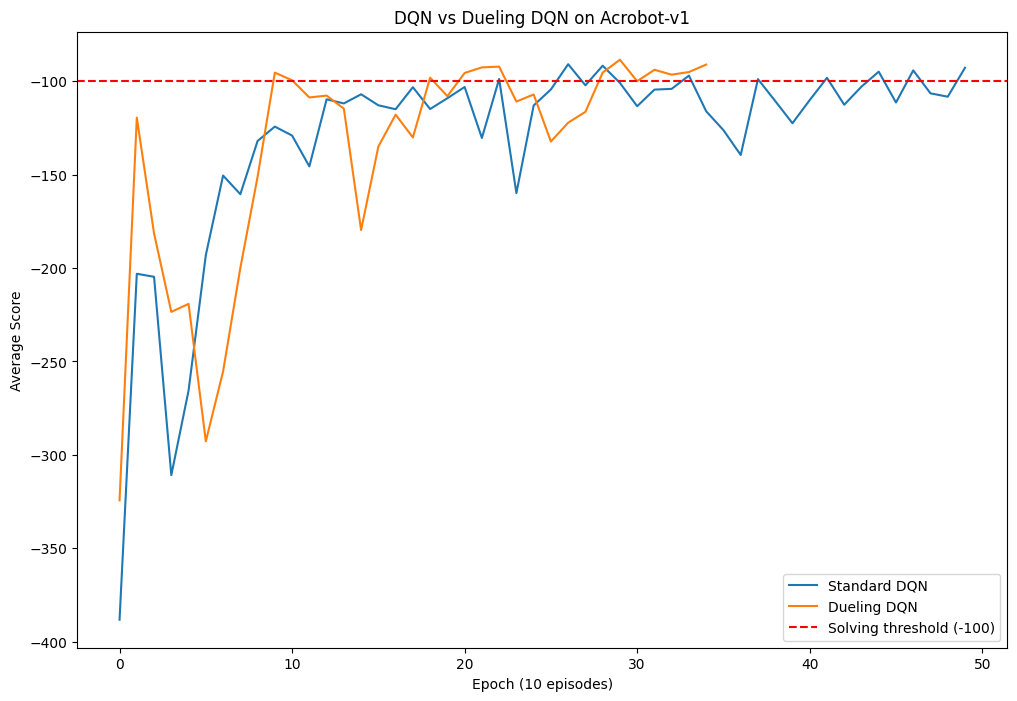

In [6]:
print("\n--- Running baseline with standard DQN ---")
baseline_scores, baseline_epochs = train(num_episodes=500, network_type="standard")

print("\n--- Running Dueling DQN ---")
dueling_scores, dueling_epochs = train(num_episodes=500, network_type="dueling")

plt.figure(figsize=(12, 8))
plt.plot(range(len(baseline_epochs)), baseline_epochs, label='Standard DQN')
plt.plot(range(len(dueling_epochs)), dueling_epochs, label='Dueling DQN')
plt.title('DQN vs Dueling DQN on Acrobot-v1')
plt.xlabel('Epoch (10 episodes)')
plt.ylabel('Average Score')
plt.axhline(y=-100, color='r', linestyle='--', label='Solving threshold (-100)')
plt.legend()
plt.savefig('dqn_vs_dueling_dqn_comparison.png')
plt.show()

